# Few-Shot, Figures & Final Table

```
MyDrive/pi-detection/
  utils/utils.py
  data/t1_llmail.parquet
  data/t2_hackaprompt.parquet
  data/t3_bipia.parquet
  results/             - JSON result files from all previous notebooks
  checkpoints/         - ewc_plus_replay checkpoints from NB5
  figures/             - output folder for plots
```

### Outputs saved to Drive:
- `results/results_fewshot.json`
- `results/ALL_RESULTS.json`
- `figures/forgetting_curves.png`
- `figures/ablation_lambda.png`
- `figures/ablation_replay.png`

## 1. Install, Mount Drive & Setup

In [1]:
!pip install -q transformers accelerate scikit-learn matplotlib seaborn

from google.colab import drive
drive.mount('/content/drive')

import os, sys, gc
import torch

# --- Update this path to wherever you uploaded your files in Google Drive ---
BASE_DIR    = '/content/drive/MyDrive/CMPE 401/Antidote'
UTILS_DIR   = os.path.join(BASE_DIR, 'utils')
DATA_DIR    = os.path.join(BASE_DIR, 'pi-detection-data')
RESULTS_DIR = os.path.join(BASE_DIR, 'results')
CKPT_DIR    = os.path.join(BASE_DIR, 'checkpoints')
FIGURES_DIR = os.path.join(BASE_DIR, 'figures')

sys.path.append(UTILS_DIR)
from utils import *

# Override CFG paths to point to Drive
CFG['checkpoint_dir'] = CKPT_DIR
CFG['results_dir']    = RESULTS_DIR
CFG['data_dir']       = DATA_DIR

os.makedirs(CKPT_DIR,    exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

print(f'Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('No GPU — figures/table cells will run fine on CPU.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB


## 2. HuggingFace Login

In [2]:
from google.colab import userdata
from huggingface_hub import login

login(userdata.get('HF_TOKEN'))

## 3. OOM Patches
*(Run always — harmless on CPU, required for few-shot GPU section)*

In [3]:
import gc, os
import utils as _utils

os.environ['PYTORCH_ALLOC_CONF'] = 'expandable_segments:True'

# Patch 1: flush GPU after checkpoint save
original_save = _utils.save_checkpoint

def save_checkpoint_and_flush(model, path):
    original_save(model, path)
    gc.collect()
    torch.cuda.empty_cache()
    free = (torch.cuda.get_device_properties(0).total_memory
            - torch.cuda.memory_allocated()) / 1e9
    print(f'  GPU cache cleared. Free VRAM: {free:.2f}GB')

_utils.save_checkpoint = save_checkpoint_and_flush

# Patch 2: gradient checkpointing to reduce activation memory
original_load_model = _utils.load_model

def load_model_with_gc():
    model = original_load_model()
    model.gradient_checkpointing_enable()
    print('  Gradient checkpointing enabled.')
    return model

_utils.load_model = load_model_with_gc

# Patch 3: clear GPU between tasks (correct scoping)
original_run_experiment = _utils.run_experiment
original_tt = _utils.train_task

def run_experiment_with_cleanup(experiment_name, tasks, tokenizer,
                                use_ewc=False, use_replay=False, joint_training=False):
    def train_task_patched(*args, **kwargs):
        result = original_tt(*args, **kwargs)
        gc.collect()
        torch.cuda.empty_cache()
        torch.cuda.synchronize()
        free = (torch.cuda.get_device_properties(0).total_memory
                - torch.cuda.memory_allocated()) / 1e9
        print(f'  Inter-task GPU cleared. Free VRAM: {free:.2f}GB')
        return result

    _utils.train_task = train_task_patched
    try:
        result = original_run_experiment(
            experiment_name, tasks, tokenizer,
            use_ewc=use_ewc, use_replay=use_replay, joint_training=joint_training
        )
    finally:
        _utils.train_task = original_tt

    return result

# Patch 4: move EWC Fisher matrices to CPU after registration to free VRAM
original_register_task = _utils.EWC.register_task

def register_task_cpu_offload(self, model, data_loader, task_name):
    original_register_task(self, model, data_loader, task_name)
    for task in self.fisher:
        for n in self.fisher[task]:
            self.fisher[task][n] = self.fisher[task][n].cpu()
    for task in self.params:
        for n in self.params[task]:
            self.params[task][n] = self.params[task][n].cpu()
    gc.collect()
    torch.cuda.empty_cache()
    free = (torch.cuda.get_device_properties(0).total_memory
            - torch.cuda.memory_allocated()) / 1e9
    print(f'  EWC data offloaded to CPU. Free VRAM: {free:.2f}GB')

_utils.EWC.register_task = register_task_cpu_offload
_utils.run_experiment = run_experiment_with_cleanup
run_experiment = run_experiment_with_cleanup

print('All patches active (with gradient checkpointing).')

All patches active (with gradient checkpointing).


## 4. Load All Prior Results
Loads JSON files from all previous notebooks saved in Drive.

In [4]:
import json

all_results = {}

result_files = {
    'baselines':        os.path.join(RESULTS_DIR, 'results_baselines.json'),
    'cl_ewc':           os.path.join(RESULTS_DIR, 'results_cl.json'),
    'cl_replay':        os.path.join(RESULTS_DIR, 'results_cl_replay.json'),
    'cl_ewc_replay':    os.path.join(RESULTS_DIR, 'results_cl_ewc_replay.json'),
    'ablation_lambda':  os.path.join(RESULTS_DIR, 'results_ablation_lambda.json'),
    'ablation_5pct':    os.path.join(RESULTS_DIR, 'results_replay_ratio_5pct.json'),
    'ablation_10pct':   os.path.join(RESULTS_DIR, 'results_replay_ratio_10pct.json'),
    'ablation_20pct':   os.path.join(RESULTS_DIR, 'results_replay_ratio_20pct.json'),
}

for name, path in result_files.items():
    if os.path.exists(path):
        with open(path) as f:
            all_results.update(json.load(f))
        print(f'Loaded: {path}')
    else:
        print(f'Not found (skipping): {path}')

fewshot_results = {}
fewshot_path = os.path.join(RESULTS_DIR, 'results_fewshot.json')
if os.path.exists(fewshot_path):
    with open(fewshot_path) as f:
        fewshot_results = json.load(f)
    print(f'Loaded: {fewshot_path}')

print(f'\nAll experiments loaded: {list(all_results.keys())}')

Loaded: /content/drive/MyDrive/CMPE 401/Antidote/results/results_baselines.json
Loaded: /content/drive/MyDrive/CMPE 401/Antidote/results/results_cl.json
Loaded: /content/drive/MyDrive/CMPE 401/Antidote/results/results_cl_replay.json
Loaded: /content/drive/MyDrive/CMPE 401/Antidote/results/results_cl_ewc_replay.json
Loaded: /content/drive/MyDrive/CMPE 401/Antidote/results/results_ablation_lambda.json
Loaded: /content/drive/MyDrive/CMPE 401/Antidote/results/results_replay_ratio_5pct.json
Loaded: /content/drive/MyDrive/CMPE 401/Antidote/results/results_replay_ratio_10pct.json
Loaded: /content/drive/MyDrive/CMPE 401/Antidote/results/results_replay_ratio_20pct.json

All experiments loaded: ['static_joint', 'naive_sequential', 'ewc_only', 'replay_only', 'ewc_plus_replay', 'ewc_lambda_100', 'ewc_lambda_1000', 'ewc_lambda_5000', 'replay_ratio_5pct', 'replay_ratio_10pct', 'replay_ratio_20pct']


## 5. Few-Shot Zero-Day Simulation
Loads `ewc_plus_replay` checkpoint after T1+T2, fine-tunes on 5 or 10 T3 examples, compares vs. from-scratch init.

**Skip this section if you already have `results_fewshot.json` in Drive.**

**GPU required for this section.**

In [5]:
import pandas as pd
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(CFG['model_name'])
tasks     = {}

for task_name, fname in [
    ('T1_LLMail',      't1_llmail.parquet'),
    ('T2_HackAPrompt', 't2_hackaprompt.parquet'),
    ('T3_BIPIA',       't3_bipia.parquet'),
]:
    path = os.path.join(DATA_DIR, fname)
    if os.path.exists(path):
        df = pd.read_parquet(path)
        tr, va, te = make_loaders(df, tokenizer)
        tasks[task_name] = {'train': tr, 'val': va, 'test': te, 'df': df}
        print(f'  {task_name}: loaded')
    else:
        print(f'  {task_name}: NOT FOUND — check your Drive path')

print(f'Loaded {len(tasks)} tasks.')

  T1_LLMail: loaded
  T2_HackAPrompt: loaded
  T3_BIPIA: loaded
Loaded 3 tasks.


In [6]:
from torch.utils.data import DataLoader

def few_shot_simulation(holdout_task_name, n_shots, cl_ckpt_dir):
    print(f'\n--- Few-shot: {n_shots}-shot on {holdout_task_name} ---')
    task_names   = list(tasks.keys())
    holdout_idx  = task_names.index(holdout_task_name)
    holdout_test = tasks[holdout_task_name]['test']
    holdout_df   = tasks[holdout_task_name]['df']

    few_shot_df = holdout_df.groupby('label').apply(
        lambda x: x.sample(n=min(n_shots // 2, len(x)), random_state=SEED)
    ).reset_index(drop=True)
    print(f'  Few-shot set: {len(few_shot_df)} samples {few_shot_df["label"].value_counts().to_dict()}')

    few_ds     = PIDataset(few_shot_df, tokenizer, CFG['max_len'])
    few_loader = DataLoader(few_ds, batch_size=min(8, len(few_shot_df)), shuffle=True)
    results    = {}

    # A) From-scratch
    scratch_model = load_model()
    train_task(scratch_model, 'scratch', few_loader, holdout_test, tokenizer, epochs=5)
    f1_scratch, _ = evaluate(scratch_model, holdout_test)
    results['from_scratch'] = round(f1_scratch, 4)
    print(f'  From-scratch F1: {f1_scratch:.4f}')
    del scratch_model
    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.synchronize()

    # B) CL-pretrained
    if holdout_idx > 0:
        prev_task = task_names[holdout_idx - 1]
        ckpt_path = os.path.join(cl_ckpt_dir, f'ewc_plus_replay_after_{prev_task}.pt')
        if os.path.exists(ckpt_path):
            cl_model = load_model()
            cl_model = load_checkpoint(cl_model, ckpt_path)
            train_task(cl_model, 'cl_pretrained', few_loader, holdout_test, tokenizer, epochs=5)
            f1_cl, _ = evaluate(cl_model, holdout_test)
            results['cl_pretrained'] = round(f1_cl, 4)
            print(f'  CL-pretrained F1: {f1_cl:.4f}')
            print(f'  Improvement from CL init: +{f1_cl - f1_scratch:.4f}')
            del cl_model
            gc.collect()
            torch.cuda.empty_cache()
        else:
            print(f'  Checkpoint not found: {ckpt_path}')
            print('  Make sure ewc_plus_replay checkpoints are in your Drive checkpoints folder.')

    return results

fewshot_results = {}

if 'T3_BIPIA' in tasks:
    for n in [5, 10]:
        key = f'few_shot_{n}'
        fewshot_results[key] = few_shot_simulation('T3_BIPIA', n, CKPT_DIR)

# Save directly to Drive
fewshot_path = os.path.join(RESULTS_DIR, 'results_fewshot.json')
with open(fewshot_path, 'w') as f:
    json.dump(fewshot_results, f, indent=2)
print(f'\nFew-shot results saved to Drive: {fewshot_path}')

/tmp/ipykernel_20707/1440008430.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  few_shot_df = holdout_df.groupby('label').apply(
`torch_dtype` is deprecated! Use `dtype` instead!



--- Few-shot: 5-shot on T3_BIPIA ---
  Few-shot set: 4 samples {0: 2, 1: 2}


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
pooler.dense.weight                     | MISSING    | 
pooler.dense.bias                       | MISSING    | 
classifier.weight                       | MISSING    | 
classifier.bias          

  Epoch 1/5 | Train Loss: 0.6351 | Val F1: 0.4975 | Val Loss: 0.6742
  Epoch 2/5 | Train Loss: 0.5679 | Val F1: 0.5172 | Val Loss: 0.6733
  Epoch 3/5 | Train Loss: 0.4467 | Val F1: 0.4932 | Val Loss: 0.6706
  Epoch 4/5 | Train Loss: 0.4381 | Val F1: 0.4780 | Val Loss: 0.6693
  Epoch 5/5 | Train Loss: 0.4683 | Val F1: 0.4900 | Val Loss: 0.6671
  Best val F1: 0.5172
  From-scratch F1: 0.5172


...

DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
pooler.dense.weight                     | MISSING    | 
pooler.dense.bias                       | MISSING    | 
classifier.weight                       | MISSING    | 
classifier.bias          

  Epoch 1/5 | Train Loss: 0.7296 | Val F1: 0.1990 | Val Loss: 0.7093
  Epoch 2/5 | Train Loss: 0.6460 | Val F1: 0.4275 | Val Loss: 0.6932
  Epoch 3/5 | Train Loss: 0.6205 | Val F1: 0.5540 | Val Loss: 0.6887
  Epoch 4/5 | Train Loss: 0.5440 | Val F1: 0.5842 | Val Loss: 0.6881
  Epoch 5/5 | Train Loss: 0.5164 | Val F1: 0.5724 | Val Loss: 0.6893
  Best val F1: 0.5842
  From-scratch F1: 0.5842


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
pooler.dense.weight                     | MISSING    | 
pooler.dense.bias                       | MISSING    | 
classifier.weight                       | MISSING    | 
classifier.bias          

  Epoch 1/5 | Train Loss: 1.6607 | Val F1: 0.1741 | Val Loss: 0.8556
  Epoch 2/5 | Train Loss: 0.6578 | Val F1: 0.6417 | Val Loss: 0.8267
  Epoch 3/5 | Train Loss: 0.3966 | Val F1: 0.6614 | Val Loss: 0.8841
  Epoch 4/5 | Train Loss: 0.3628 | Val F1: 0.6614 | Val Loss: 0.9219
  Epoch 5/5 | Train Loss: 0.3334 | Val F1: 0.6586 | Val Loss: 0.9367
  Best val F1: 0.6614
  CL-pretrained F1: 0.6614
  Improvement from CL init: +0.0772

Few-shot results saved to Drive: /content/drive/MyDrive/CMPE 401/Antidote/results/results_fewshot.json


## 6. Figures
Generates and saves all three paper figures to Drive. CPU-safe — no GPU needed.

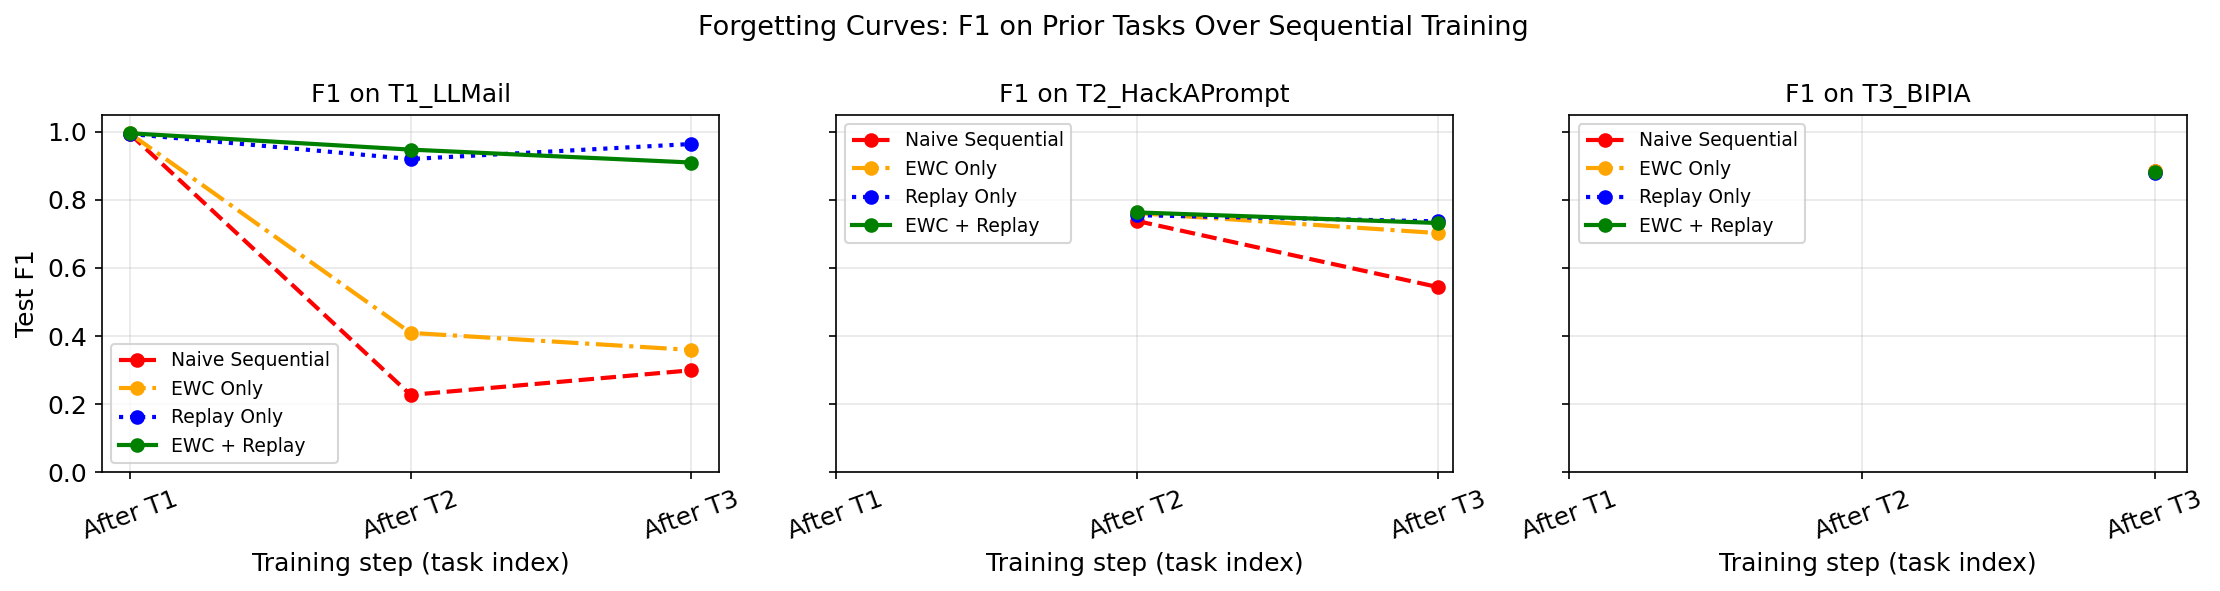

Saved: /content/drive/MyDrive/CMPE 401/Antidote/figures/forgetting_curves.png


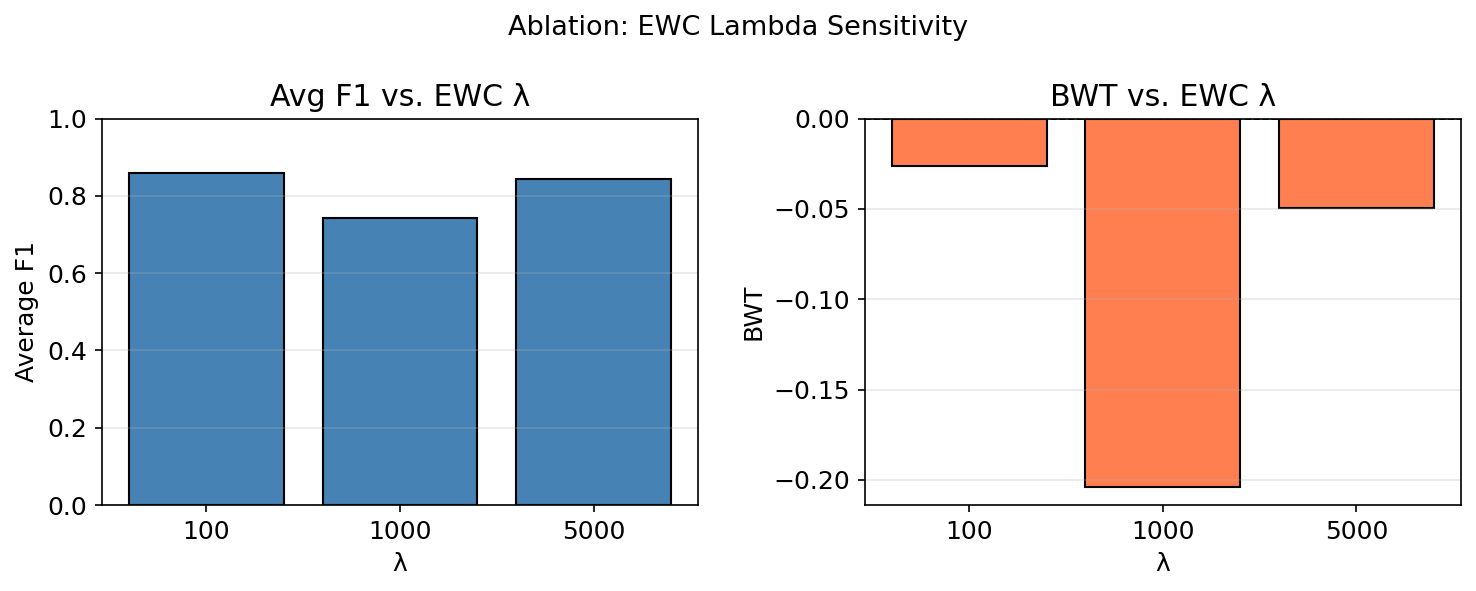

Saved: /content/drive/MyDrive/CMPE 401/Antidote/figures/ablation_lambda.png


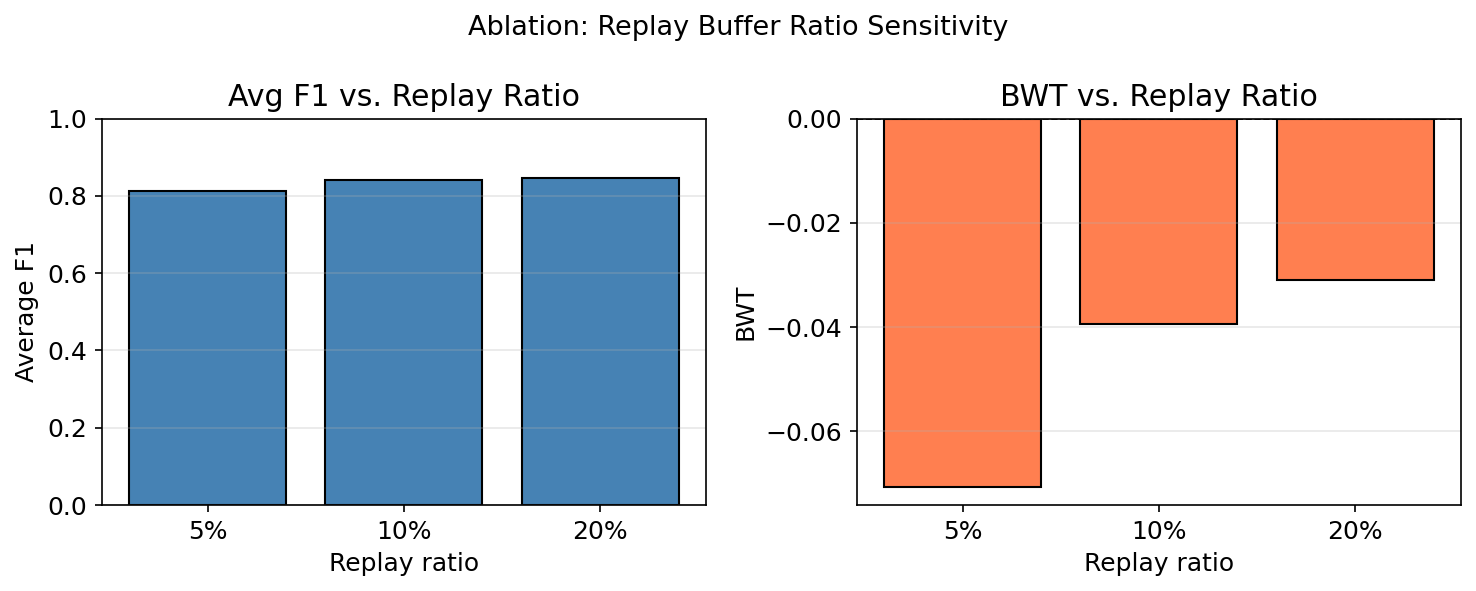

Saved: /content/drive/MyDrive/CMPE 401/Antidote/figures/ablation_replay.png


In [7]:
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

matplotlib.rcParams.update({'font.size': 12, 'figure.dpi': 150})

task_names = ['T1_LLMail', 'T2_HackAPrompt', 'T3_BIPIA']

# --- Figure 1: Forgetting Curves ---
methods_to_plot = {
    'naive_sequential': ('Naive Sequential', 'red',    '--'),
    'ewc_only':         ('EWC Only',         'orange', '-.'),
    'replay_only':      ('Replay Only',      'blue',   ':'),
    'ewc_plus_replay':  ('EWC + Replay',     'green',  '-'),
}

fig, axes = plt.subplots(1, len(task_names), figsize=(5 * len(task_names), 4), sharey=True)
for ax_idx, focus_task in enumerate(task_names):
    ax = axes[ax_idx]
    j  = task_names.index(focus_task)
    for exp_key, (label, color, ls) in methods_to_plot.items():
        r = all_results.get(exp_key)
        if not r or 'results_matrix' not in r:
            continue
        matrix = r['results_matrix']
        y_vals, x_vals = [], []
        for i in range(j, len(task_names)):
            if matrix[i][j] is not None and matrix[i][j] > 0:
                y_vals.append(matrix[i][j])
                x_vals.append(i)
        if y_vals:
            ax.plot(x_vals, y_vals, label=label, color=color, linestyle=ls, marker='o', linewidth=2)
    ax.set_title(f'F1 on {focus_task}', fontsize=12)
    ax.set_xlabel('Training step (task index)')
    ax.set_ylabel('Test F1' if ax_idx == 0 else '')
    ax.set_xticks(range(len(task_names)))
    ax.set_xticklabels([f'After T{i+1}' for i in range(len(task_names))], rotation=20)
    ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)

plt.suptitle('Forgetting Curves: F1 on Prior Tasks Over Sequential Training', fontsize=13)
plt.tight_layout()
fig1_path = os.path.join(FIGURES_DIR, 'forgetting_curves.png')
plt.savefig(fig1_path, bbox_inches='tight')
plt.show()
print(f'Saved: {fig1_path}')

# --- Figure 2: EWC Lambda Ablation ---
lambdas = [100, 1000, 5000]
avg_f1s = [all_results.get(f'ewc_lambda_{l}', {}).get('avg_f1', 0) for l in lambdas]
bwts    = [all_results.get(f'ewc_lambda_{l}', {}).get('cl_metrics', {}).get('BWT', 0) for l in lambdas]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.bar([str(l) for l in lambdas], avg_f1s, color='steelblue', edgecolor='black')
ax1.set_title('Avg F1 vs. EWC λ'); ax1.set_xlabel('λ'); ax1.set_ylabel('Average F1')
ax1.set_ylim(0, 1); ax1.grid(axis='y', alpha=0.3)
ax2.bar([str(l) for l in lambdas], bwts, color='coral', edgecolor='black')
ax2.set_title('BWT vs. EWC λ'); ax2.set_xlabel('λ'); ax2.set_ylabel('BWT')
ax2.axhline(y=0, color='black', linewidth=0.8, linestyle='--'); ax2.grid(axis='y', alpha=0.3)
plt.suptitle('Ablation: EWC Lambda Sensitivity', fontsize=13)
plt.tight_layout()
fig2_path = os.path.join(FIGURES_DIR, 'ablation_lambda.png')
plt.savefig(fig2_path, bbox_inches='tight')
plt.show()
print(f'Saved: {fig2_path}')

# --- Figure 3: Replay Ratio Ablation ---
ratios    = [5, 10, 20]
avg_f1s_r = [all_results.get(f'replay_ratio_{r}pct', {}).get('avg_f1', 0) for r in ratios]
bwts_r    = [all_results.get(f'replay_ratio_{r}pct', {}).get('cl_metrics', {}).get('BWT', 0) for r in ratios]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.bar([f'{r}%' for r in ratios], avg_f1s_r, color='steelblue', edgecolor='black')
ax1.set_title('Avg F1 vs. Replay Ratio'); ax1.set_xlabel('Replay ratio'); ax1.set_ylabel('Average F1')
ax1.set_ylim(0, 1); ax1.grid(axis='y', alpha=0.3)
ax2.bar([f'{r}%' for r in ratios], bwts_r, color='coral', edgecolor='black')
ax2.set_title('BWT vs. Replay Ratio'); ax2.set_xlabel('Replay ratio'); ax2.set_ylabel('BWT')
ax2.axhline(y=0, color='black', linewidth=0.8, linestyle='--'); ax2.grid(axis='y', alpha=0.3)
plt.suptitle('Ablation: Replay Buffer Ratio Sensitivity', fontsize=13)
plt.tight_layout()
fig3_path = os.path.join(FIGURES_DIR, 'ablation_replay.png')
plt.savefig(fig3_path, bbox_inches='tight')
plt.show()
print(f'Saved: {fig3_path}')

## 7. Final Paper-Ready Tables

In [8]:
import json

# Merge everything
combined = dict(all_results)
combined['few_shot'] = fewshot_results

all_results_path = os.path.join(RESULTS_DIR, 'ALL_RESULTS.json')
with open(all_results_path, 'w') as f:
    json.dump(combined, f, indent=2)
print(f'Saved: {all_results_path}')

task_names = ['T1_LLMail', 'T2_HackAPrompt', 'T3_BIPIA']
main_exps  = ['static_joint', 'naive_sequential', 'ewc_only', 'replay_only', 'ewc_plus_replay']

print('\n' + '='*80)
print('PAPER TABLE 1 — MAIN RESULTS')
print('='*80)
header = f'{"Method":<22}' + ''.join(f'{t:<18}' for t in task_names) + f'{"Avg F1":<10}{"BWT":<10}'
print(header)
print('-'*80)
for exp in main_exps:
    if exp not in combined:
        print(f'  {exp}: NOT RUN')
        continue
    r   = combined[exp]
    row = f'{exp:<22}'
    for t in task_names:
        row += f'{r["per_task_f1"].get(t, 0.0):<18.4f}'
    row += f'{r["avg_f1"]:<10.4f}'
    row += f'{str(r.get("cl_metrics", {}).get("BWT", "N/A")):<10}'
    print(row)
print('='*80)

print('\n' + '='*50)
print('PAPER TABLE 2 — FEW-SHOT ZERO-DAY (T3/BIPIA)')
print('='*50)
print(f'{"Init":<20}{"5-shot F1":<15}{"10-shot F1":<15}')
print('-'*50)
for init in ['from_scratch', 'cl_pretrained']:
    f5  = fewshot_results.get('few_shot_5',  {}).get(init, 'N/A')
    f10 = fewshot_results.get('few_shot_10', {}).get(init, 'N/A')
    print(f'{init:<20}{str(f5):<15}{str(f10):<15}')
print('='*50)

Saved: /content/drive/MyDrive/CMPE 401/Antidote/results/ALL_RESULTS.json

PAPER TABLE 1 — MAIN RESULTS
Method                T1_LLMail         T2_HackAPrompt    T3_BIPIA          Avg F1    BWT       
--------------------------------------------------------------------------------
static_joint          0.9899            0.7938            0.8829            0.8889    0.8919    
naive_sequential      0.2998            0.5437            0.8854            0.5763    -0.4438   
ewc_only              0.3594            0.7021            0.8847            0.6488    -0.3468   
replay_only           0.9635            0.7365            0.8798            0.8599    -0.0238   
ewc_plus_replay       0.9091            0.7318            0.8816            0.8408    -0.0584   

PAPER TABLE 2 — FEW-SHOT ZERO-DAY (T3/BIPIA)
Init                5-shot F1      10-shot F1     
--------------------------------------------------
from_scratch        0.5172         0.5842         
cl_pretrained       0.5787         